# SED and monochromatic interferometry: component checks
This section runs independently of the ALMA checks above. Set the model path in the settings cell.

Compare MCFOST alone with MCFOST + the 4000 K accretion secondary, intrinsically and with a common foreground extinction screen. The secondary contributes 3.9% of their combined flux at 1.65 μm.

Overresolved emission is disabled: it is neither fitted nor added to the SED or interferometric predictions here. Optional interferometric background support remains available in the library. No MCFOST or SMAC runs are launched.


In [31]:
from pathlib import Path
import sys
import importlib
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import tempfile
from IPython.display import Image
from IPython.display import display

SED_IF_REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / 'lib/obriy_interferometry.py').is_file())
if str(SED_IF_REPO) not in sys.path:
    sys.path.insert(0, str(SED_IF_REPO))
import distroi
import lib.obriy_sed as obs
import lib.obriy_interferometry as obi

importlib.reload(obs)
importlib.reload(obi)

# Trial directory containing data_th/ and data_1.65/, data_2.2/, etc.
SED_IF_MODEL_DIR = Path("/Users/katerynaandrych/Work/lin/Postdoc/ozstar/ozstar_model/trial_seed1562913011_budget14.10_20260805-233423")  # e.g. Path('/path/to/trial'); independent of ALMA MODEL_DIR
IF_DATA_ROOT = Path('/Users/katerynaandrych/Work/lin/Postdoc/Data/interferometry/IRAS08544-4431')
SED_DATA_ROOT = Path('/Users/katerynaandrych/Work/lin/Postdoc/Data/SED_reddening/IRAS08544-4431')
SED_PHOTOMETRY = SED_DATA_ROOT / 'IRAS08544-4431.phot'
SED_IF_LAW = SED_IF_REPO / 'utils/ISMreddening_law_Cardelli1989.dat'
SED_IF_EBV = None  # None: fit to MCFOST + secondary, as in production; otherwise fixed >= 0

BAND_SPECS = {
    'PIONIER': ('PIONIER', '*.fits', (1.63, 1.64), 1.63, 'vis2'),
    'GRAVITY': ('GRAVITY', '*1.fits', (2.199, 2.201), 2.2, 'vis2'),
    'MATISSE L': ('MATISSE_L', '*.fits', (3.48, 3.52), 3.5, 'vis2'),
    'MATISSE N': ('MATISSE_N', '*.fits', (9.9, 10.1), 10.0, 'vis'),
}
# Start every run with fresh state; missing inputs are reported explicitly.
sed_if_ready = False
sed_if_bands = {}
sed_if_results = {}
SED_IF_PLOT_DIR = Path(tempfile.mkdtemp(prefix="sed_obi_"))
print("Diagnostic figures:", SED_IF_PLOT_DIR)


Diagnostic figures: /var/folders/wd/7j5253z130s18knwp68vbvpc0000gp/T/sed_obi_bajmja4v


## Load SED and fit the common foreground extinction
Reads the same MCFOST SED and photometry as production. The extinction fit uses only MCFOST + secondary, and this single E(B−V) is then held fixed for every displayed stage. Missing files skip the dependent cells; invalid data raise an error.

In [32]:
sed_if_ready = False
sed_if_bands = {}
sed_if_results = {}
if SED_IF_MODEL_DIR is None:
    print('Set SED_IF_MODEL_DIR in the settings cell, then rerun this section.')
else:
    sed_if_trial = Path(SED_IF_MODEL_DIR).expanduser()
    sed_if_path = sed_if_trial / 'data_th/sed_rt.fits.gz'
    if not sed_if_path.is_file() or not SED_PHOTOMETRY.is_file():
        print('Missing SED input:', sed_if_path, 'or', SED_PHOTOMETRY)
    else:
        with fits.open(sed_if_path) as hdul:
            sed_if_lam = np.asarray(hdul[1].data, dtype=float).copy()
            sed_if_base = np.asarray(hdul[0].data[0, 0, 0, :], dtype=float).copy() * 1e3
        order = np.argsort(sed_if_lam)
        sed_if_lam, sed_if_base = sed_if_lam[order], sed_if_base[order]
        sed_if_with_secondary, sed_if_secondary = obs.add_blackbody_component(sed_if_lam, sed_if_base)
        sed_if_data_wave, sed_if_data_flux, sed_if_data_err = map(
            np.asarray, obs.load_sed_data(str(SED_PHOTOMETRY)))
        assert np.all(np.isfinite(sed_if_data_flux)) and np.all(np.isfinite(sed_if_data_err))
        assert np.all(sed_if_data_err > 0) and len(sed_if_data_wave) > 1
        assert sed_if_data_wave.min() >= sed_if_lam.min() and sed_if_data_wave.max() <= sed_if_lam.max()
        if SED_IF_EBV is None:
            sed_if_ebv = obs.fit_sed_reddening(
                sed_if_data_wave, sed_if_data_flux, sed_if_data_err,
                sed_if_lam, sed_if_with_secondary, str(SED_IF_LAW))
        else:
            sed_if_ebv = float(SED_IF_EBV)
        assert np.isfinite(sed_if_ebv) and sed_if_ebv >= 0
        sed_if_model_sed = distroi.read_sed_mcfost(str(sed_if_path))
        sed_if_ready = True
        print(f'E(B-V) = {sed_if_ebv:.6g}; flux unit: lambda F_lambda [erg/s/cm²]')

E(B-V) = 1.39763; flux unit: lambda F_lambda [erg/s/cm²]


## Load narrow-band interferometry
Load the explicit monochromatic selections. Missing instruments are skipped. MATISSE N uses correlated flux in Jy; the other bands use V². No overresolved component is fitted or added.


In [33]:
sed_if_background = None
sed_if_bands = {}
if not sed_if_ready:
    print('SKIPPED: load the SED first.')
else:
    for name, (folder, pattern, limits, wavelength, vistype) in BAND_SPECS.items():
        directory = IF_DATA_ROOT / folder
        model_dir = sed_if_trial / f'data_{wavelength}'
        if not list(directory.glob(pattern)) or not model_dir.is_dir():
            print(f'SKIPPED {name}: missing OIFITS or {model_dir}')
            continue
        images = distroi.read_image_list(str(sed_if_trial), f'data_{wavelength}/')
        if len(images) != 1:
            raise ValueError(f'{name}: expected exactly one model image, found {len(images)}')
        if not np.isclose(images[0].wavelength, wavelength):
            raise ValueError(f'{name}: image wavelength does not match directory')
        data = distroi.read_oi_container_from_oifits(
            str(directory) + '/', pattern, wave_lims=limits, fcorr=(vistype == 'vis'))
        # Promote wavelength precision before Distroi evaluates frequency**3.
        for attribute in ("v_wave", "v2_wave", "t3_wave"):
            values = getattr(data, attribute, None)
            if values is not None:
                setattr(data, attribute, np.asarray(values, dtype=np.float64))
        sed_if_bands[name] = dict(data=data, images=images, vistype=vistype)


2026-09-11 01:10:33,498 - distroi.auxiliary.read_oifits - INFO: Reading from /Users/katerynaandrych/Work/lin/Postdoc/Data/interferometry/IRAS08544-4431/PIONIER/*.fits
2026-09-11 01:10:33,499 - distroi.auxiliary.read_oifits - INFO: Reading IRAS08544-4431_PIONIER_data2015ep.fits...
2026-09-11 01:10:33,500 - distroi.auxiliary.read_oifits - INFO: Reading OI_WAVELENGTH
2026-09-11 01:10:33,506 - distroi.auxiliary.read_oifits - INFO: Reading OI_WAVELENGTH
2026-09-11 01:10:33,508 - distroi.auxiliary.read_oifits - INFO: Reading OI_WAVELENGTH
2026-09-11 01:10:33,509 - distroi.auxiliary.read_oifits - INFO: Reading OI_TARGET
2026-09-11 01:10:33,511 - distroi.auxiliary.read_oifits - INFO: Reading OI_ARRAY
2026-09-11 01:10:33,512 - distroi.auxiliary.read_oifits - INFO: Reading OI_VIS2
2026-09-11 01:10:33,514 - distroi.auxiliary.read_oifits - INFO: Reading OI_VIS2
2026-09-11 01:10:33,516 - distroi.auxiliary.read_oifits - INFO: Reading OI_VIS2
2026-09-11 01:10:33,517 - distroi.auxiliary.read_oifits - 

## SED comparisons using the production plotting helper
The first figure shows intrinsic spectra; the second applies the common fitted E(B−V). Both use `lib.obriy_sed.plot_sed_secondary_comparison`, preserving production styling. Photometry is observed, not dereddened: the intrinsic panel is for component inspection.

The diagnostic table retains the existing 1.5–14 μm selection and calls `chi2reddened`. No background is included. Figures are saved in a temporary diagnostic directory.


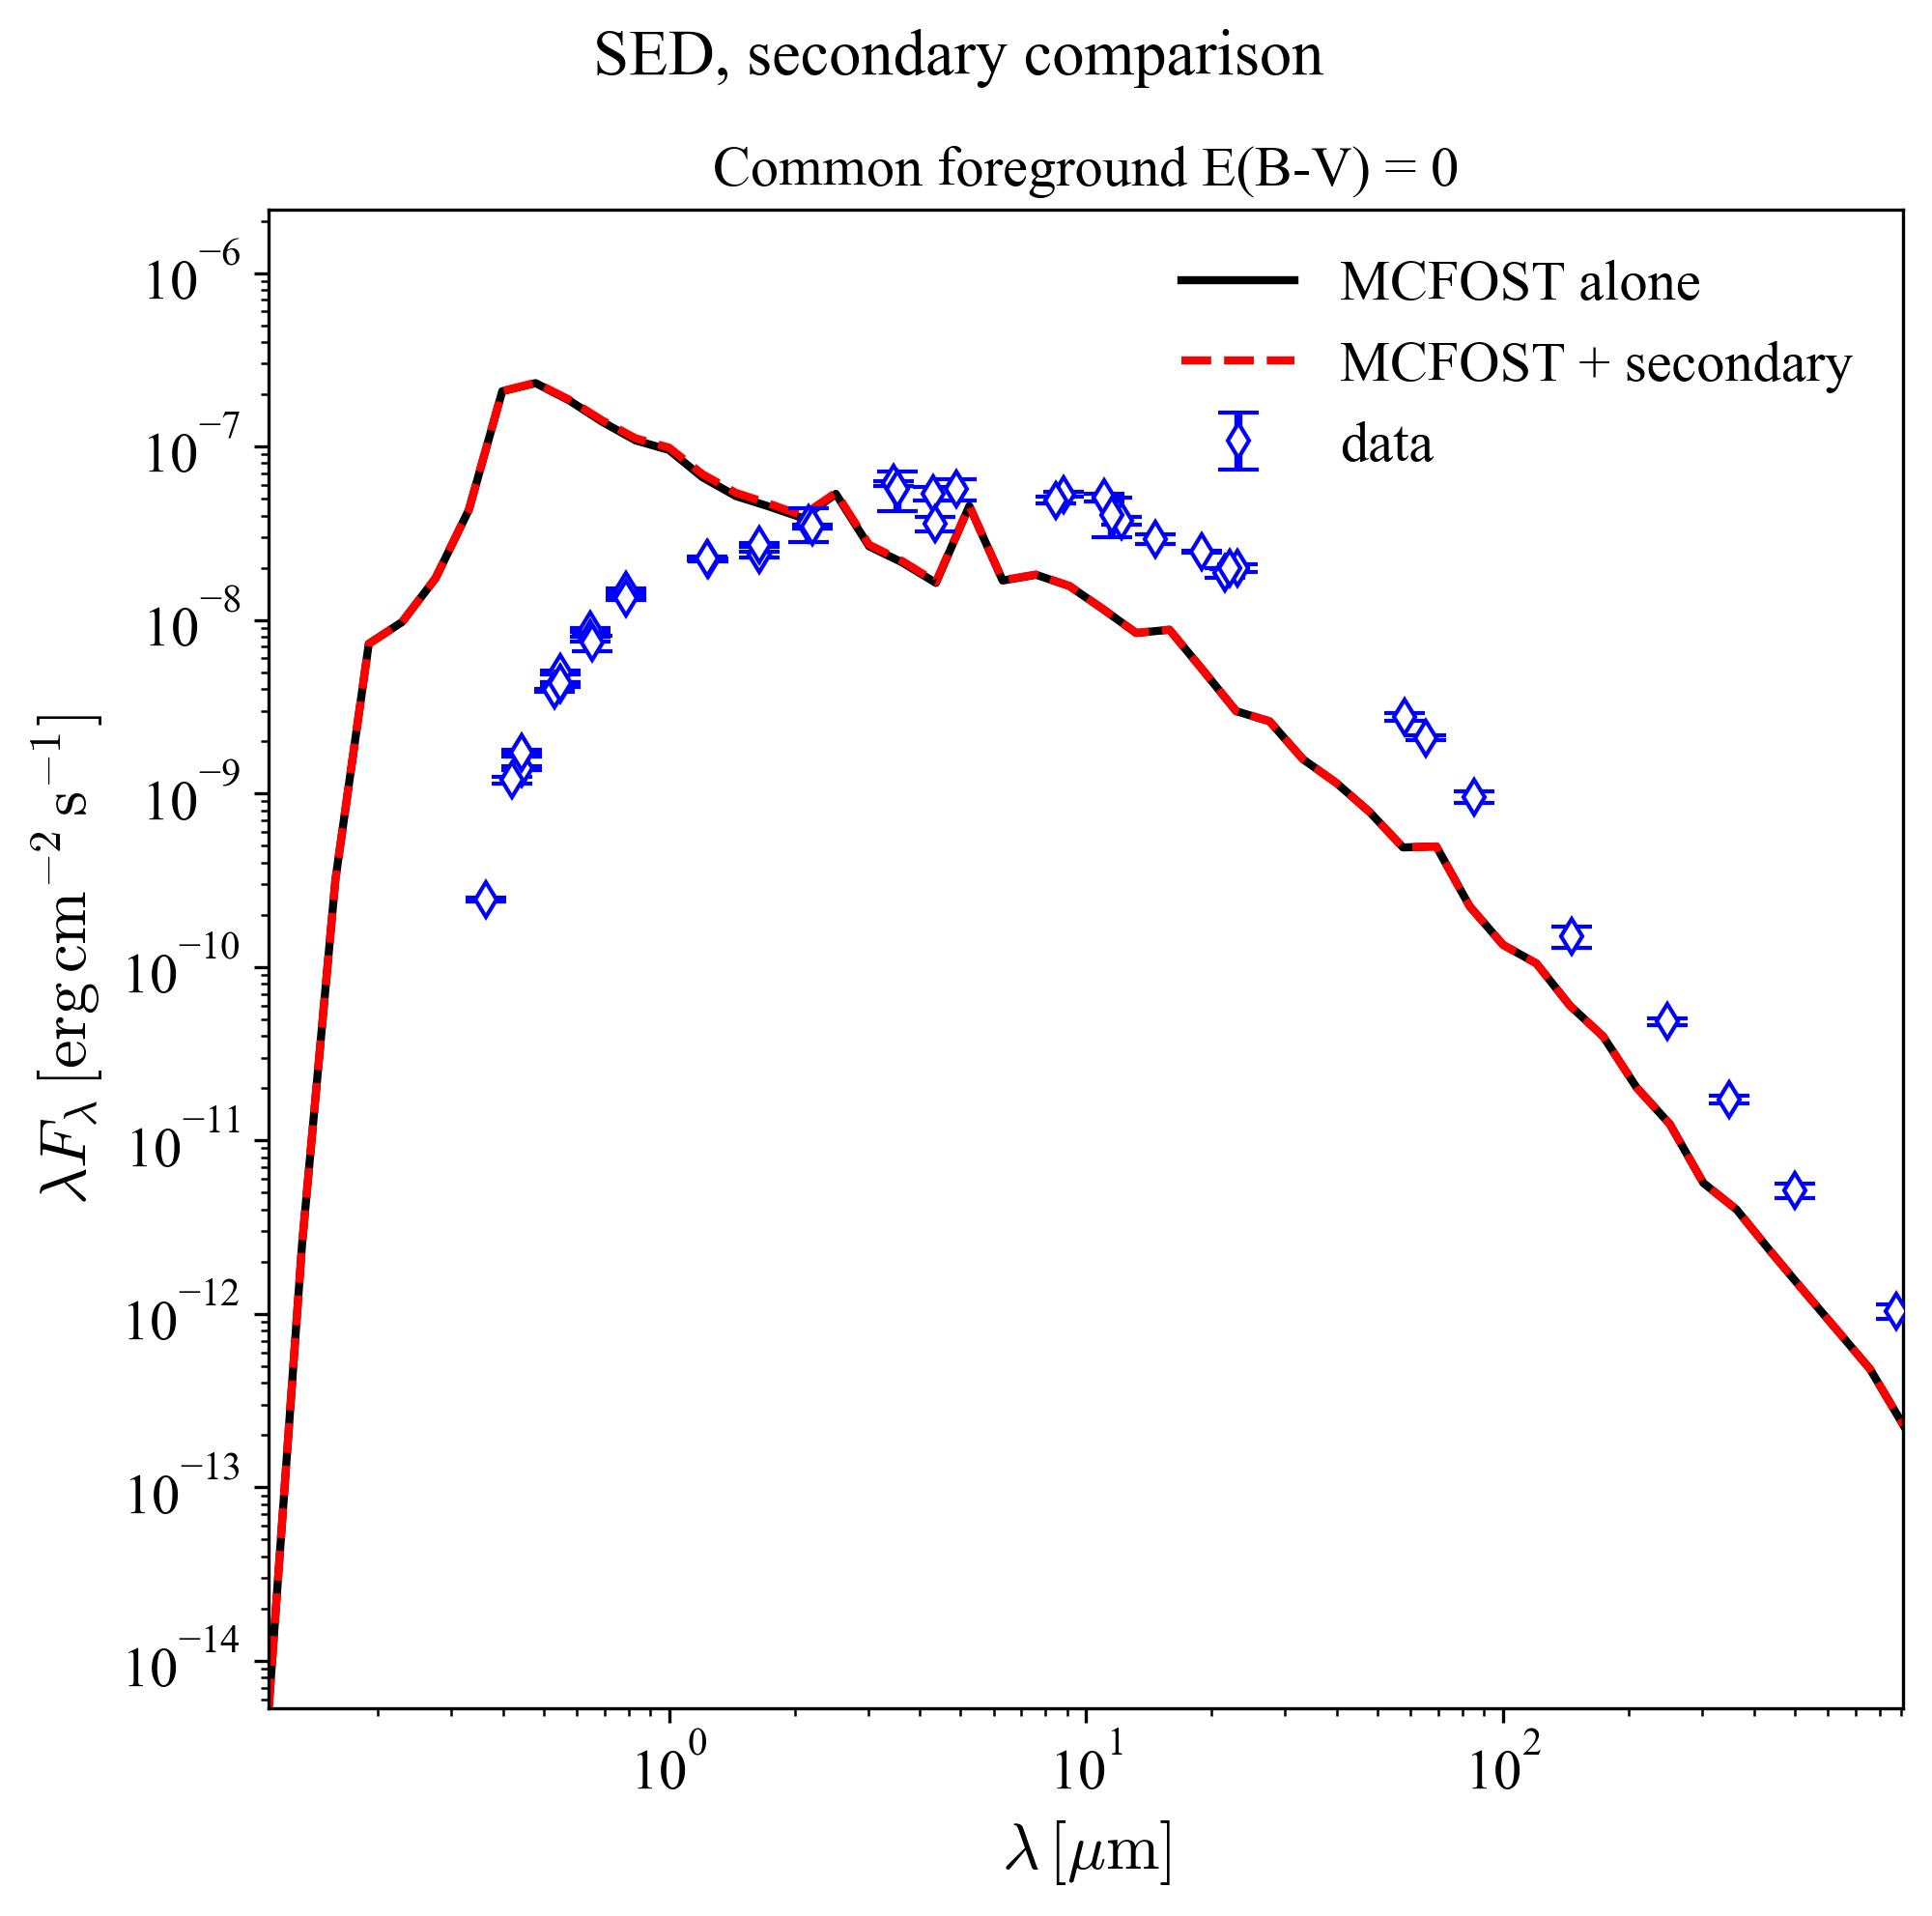

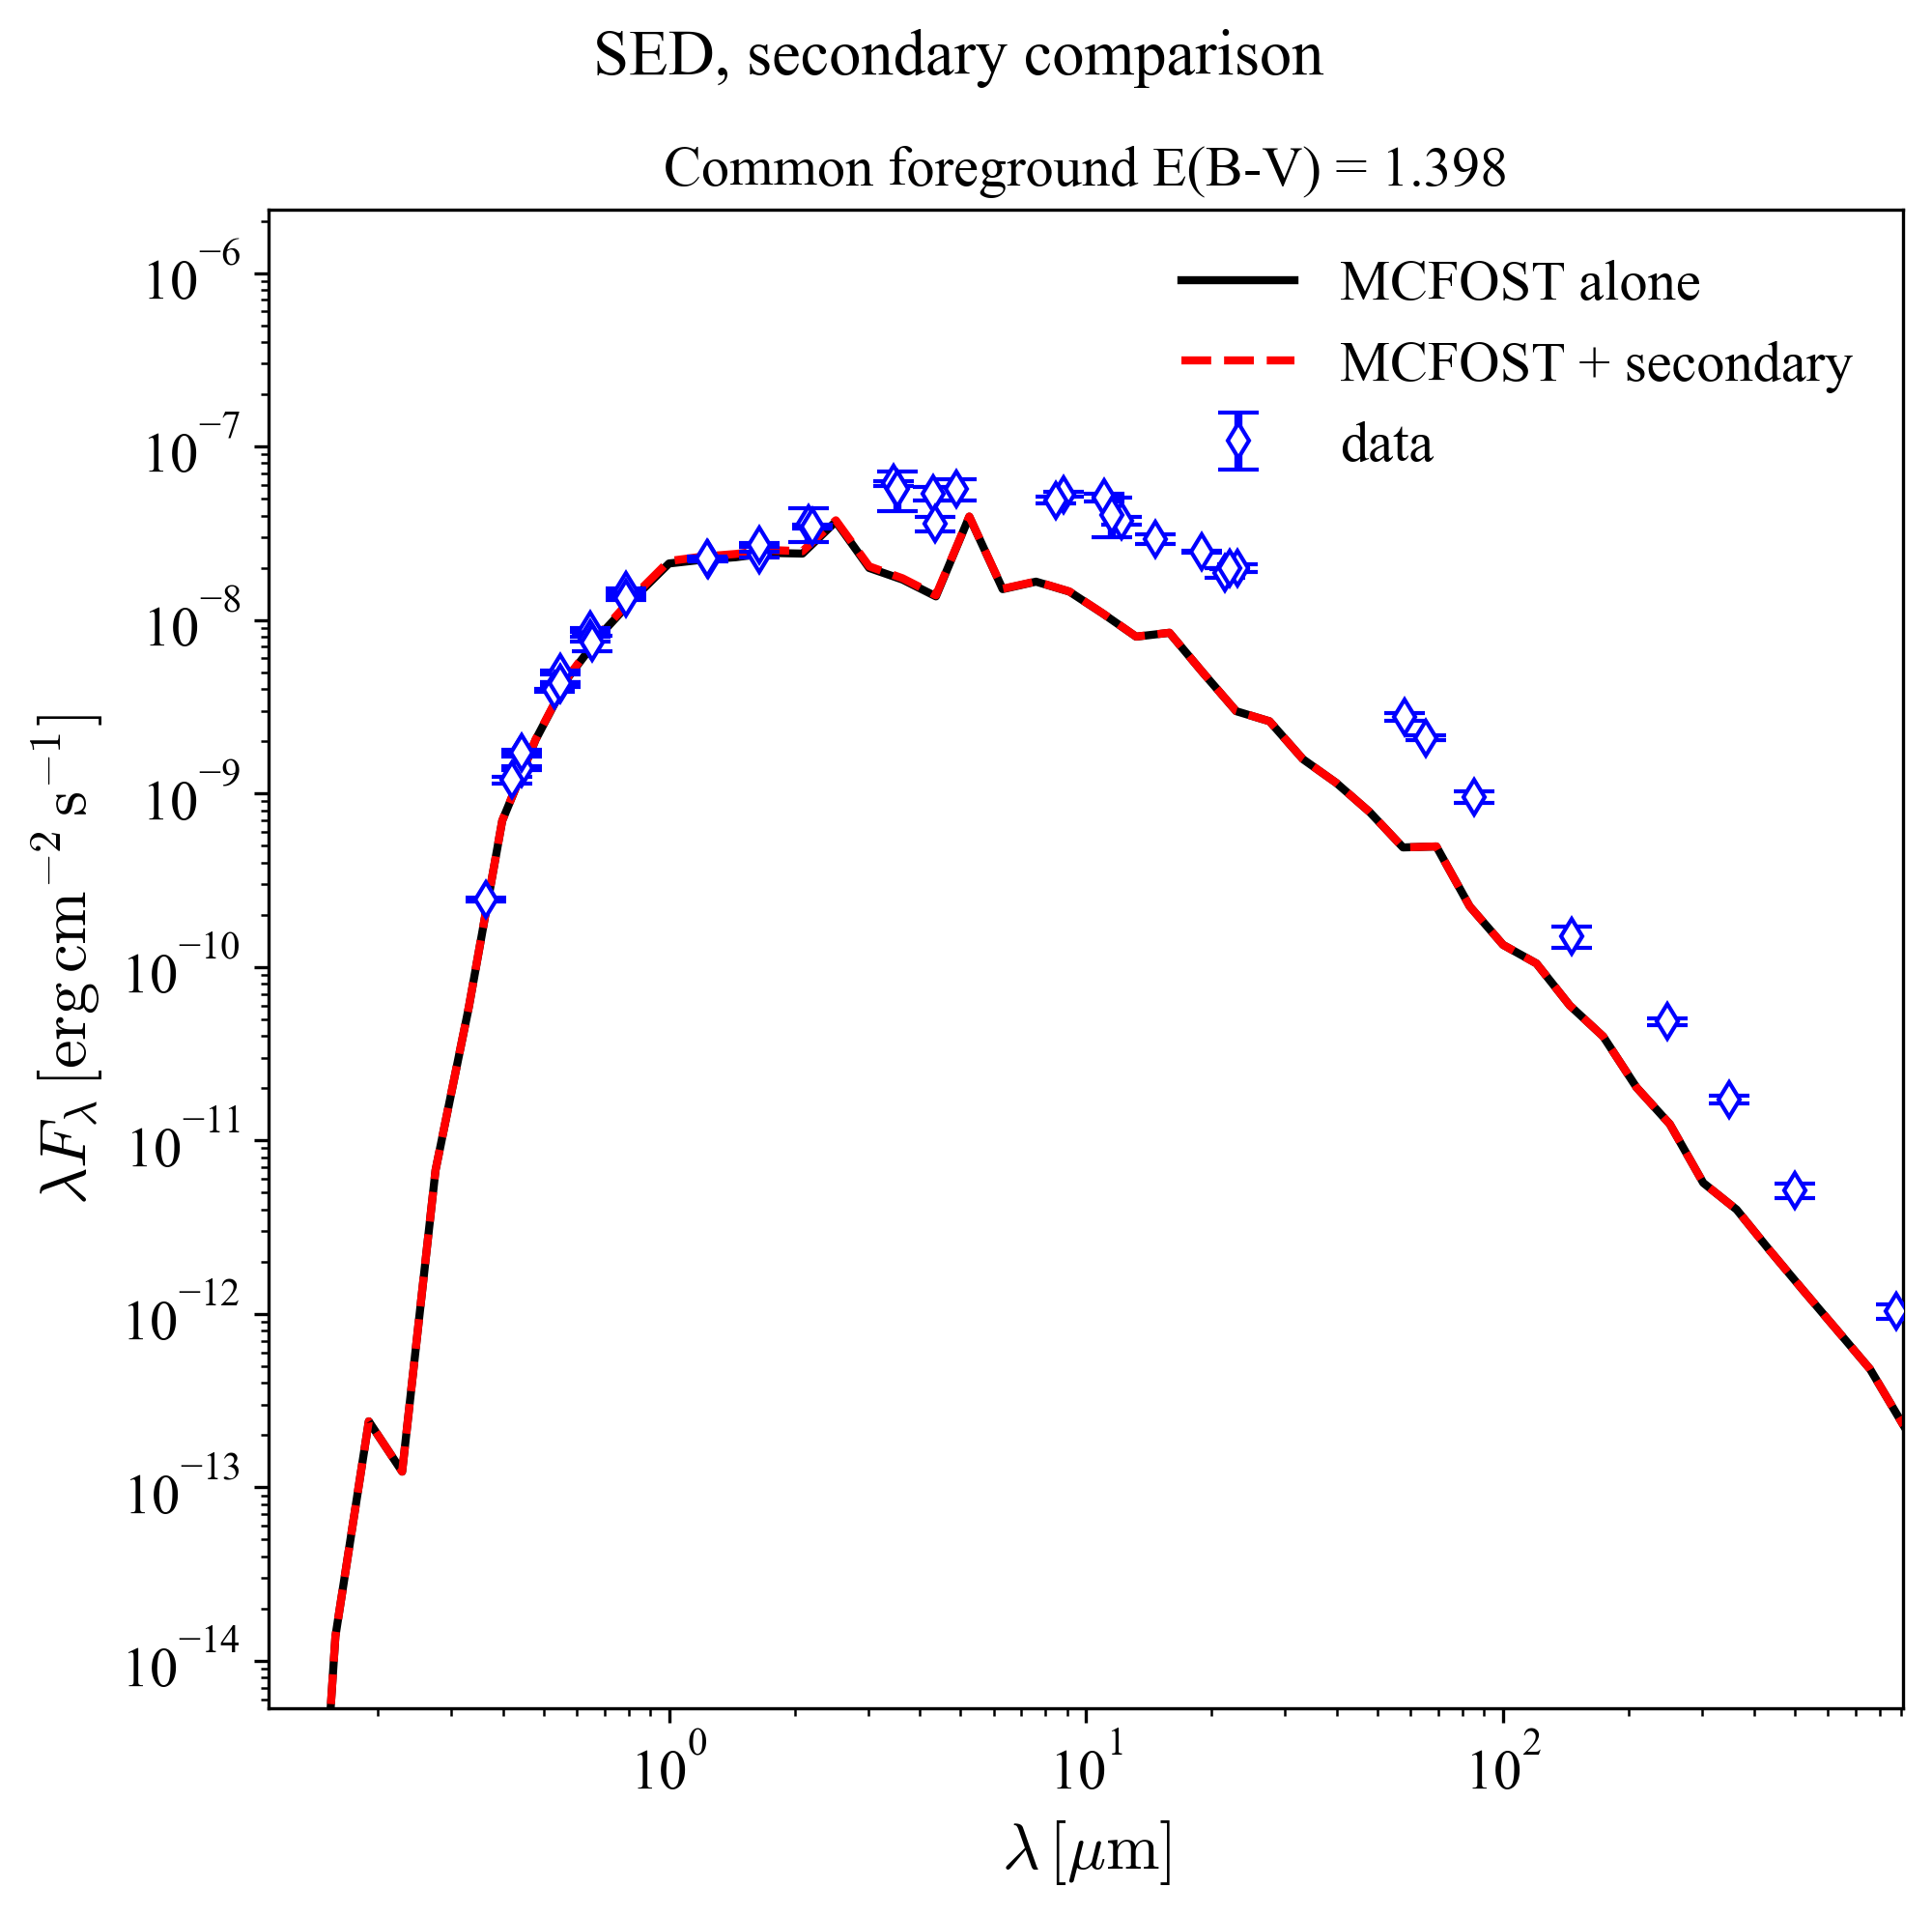

,stage,diagnostic_chi2,chi2_per_Nminus1,N
0,MCFOST only,2346.770079,180.520775,14
1,MCFOST + secondary,2313.841158,177.987781,14


In [34]:
if not sed_if_ready:
    print('SKIPPED: load the SED first.')
else:
    sed_if_stages = {'MCFOST only': sed_if_base, 'MCFOST + secondary': sed_if_with_secondary}
    for title, ebv in [('intrinsic', 0.0), ('reddened', sed_if_ebv)]:
        output = SED_IF_PLOT_DIR / f'SED_secondary_{title}.png'
        obs.plot_sed_secondary_comparison(
            sed_if_data_wave, sed_if_data_flux, sed_if_data_err, sed_if_lam,
            sed_if_base, sed_if_with_secondary, str(SED_IF_LAW), ebv, output)
        display(Image(filename=str(output)))
    rows = []
    score_mask = (sed_if_data_wave >= 1.5) & (sed_if_data_wave <= 14.)
    for label, spectrum in sed_if_stages.items():
        if score_mask.sum() > 1:
            reduced, total, _ = obs.chi2reddened(
                sed_if_data_wave[score_mask], sed_if_data_flux[score_mask], sed_if_lam,
                spectrum, sed_if_data_err[score_mask], str(SED_IF_LAW), sed_if_ebv)
            rows.append(dict(stage=label, diagnostic_chi2=total, chi2_per_Nminus1=reduced, N=int(score_mask.sum())))
    display(pd.DataFrame(rows))

## Monochromatic interferometry: data and two stages
Compare MCFOST alone and MCFOST + secondary with the same intrinsic SED and foreground E(B−V). No background is included. Predictions are evaluated at the observed spatial frequencies; points are not joined because baseline orientations differ.

Checks verify that foreground extinction cancels in V² and attenuates correlated flux consistently with the SED helper. These are numerical consistency checks, not proof of a good physical fit.


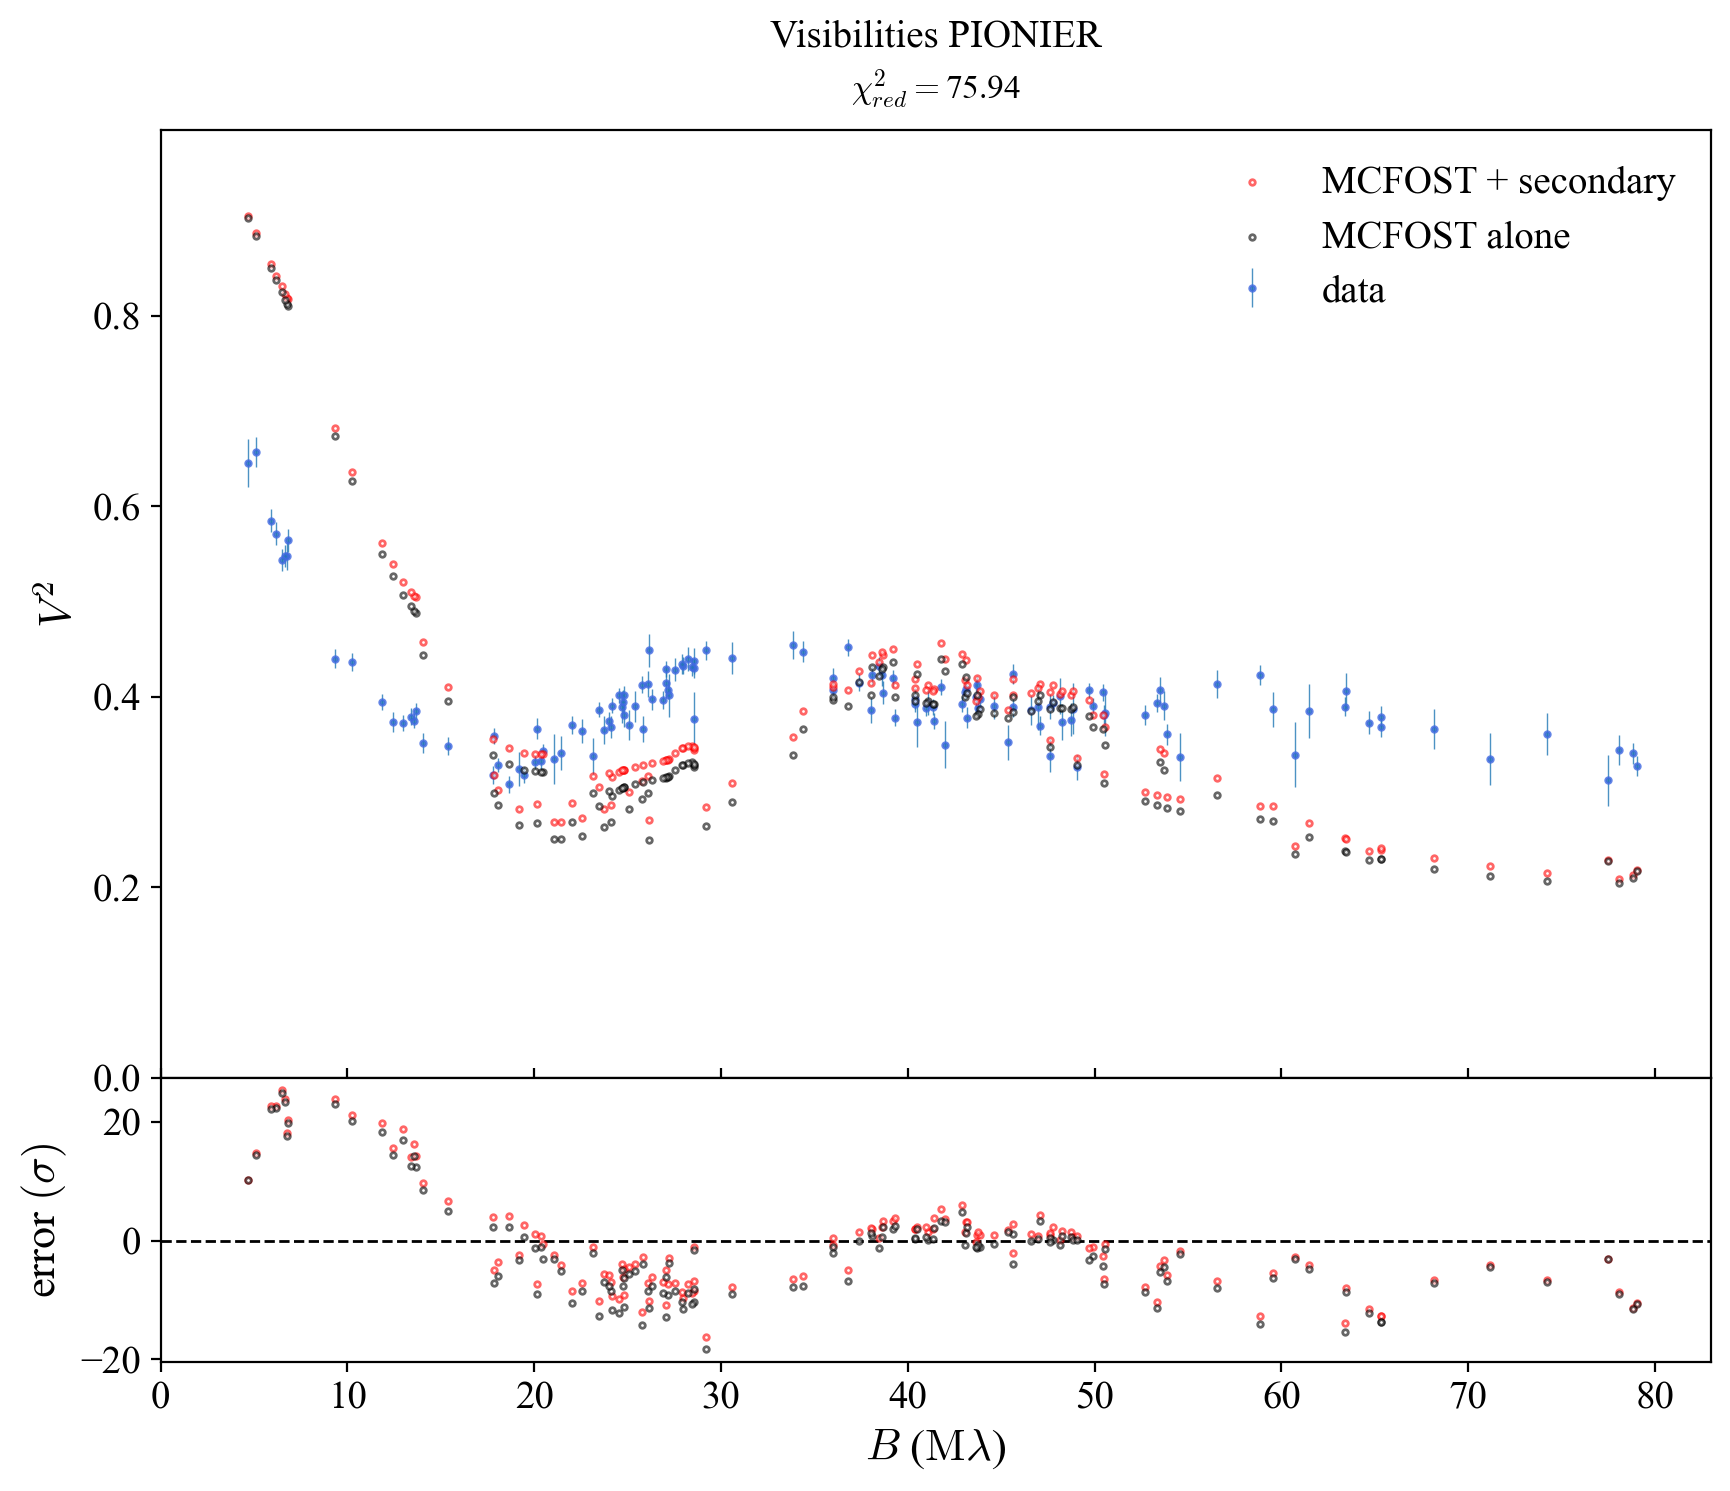

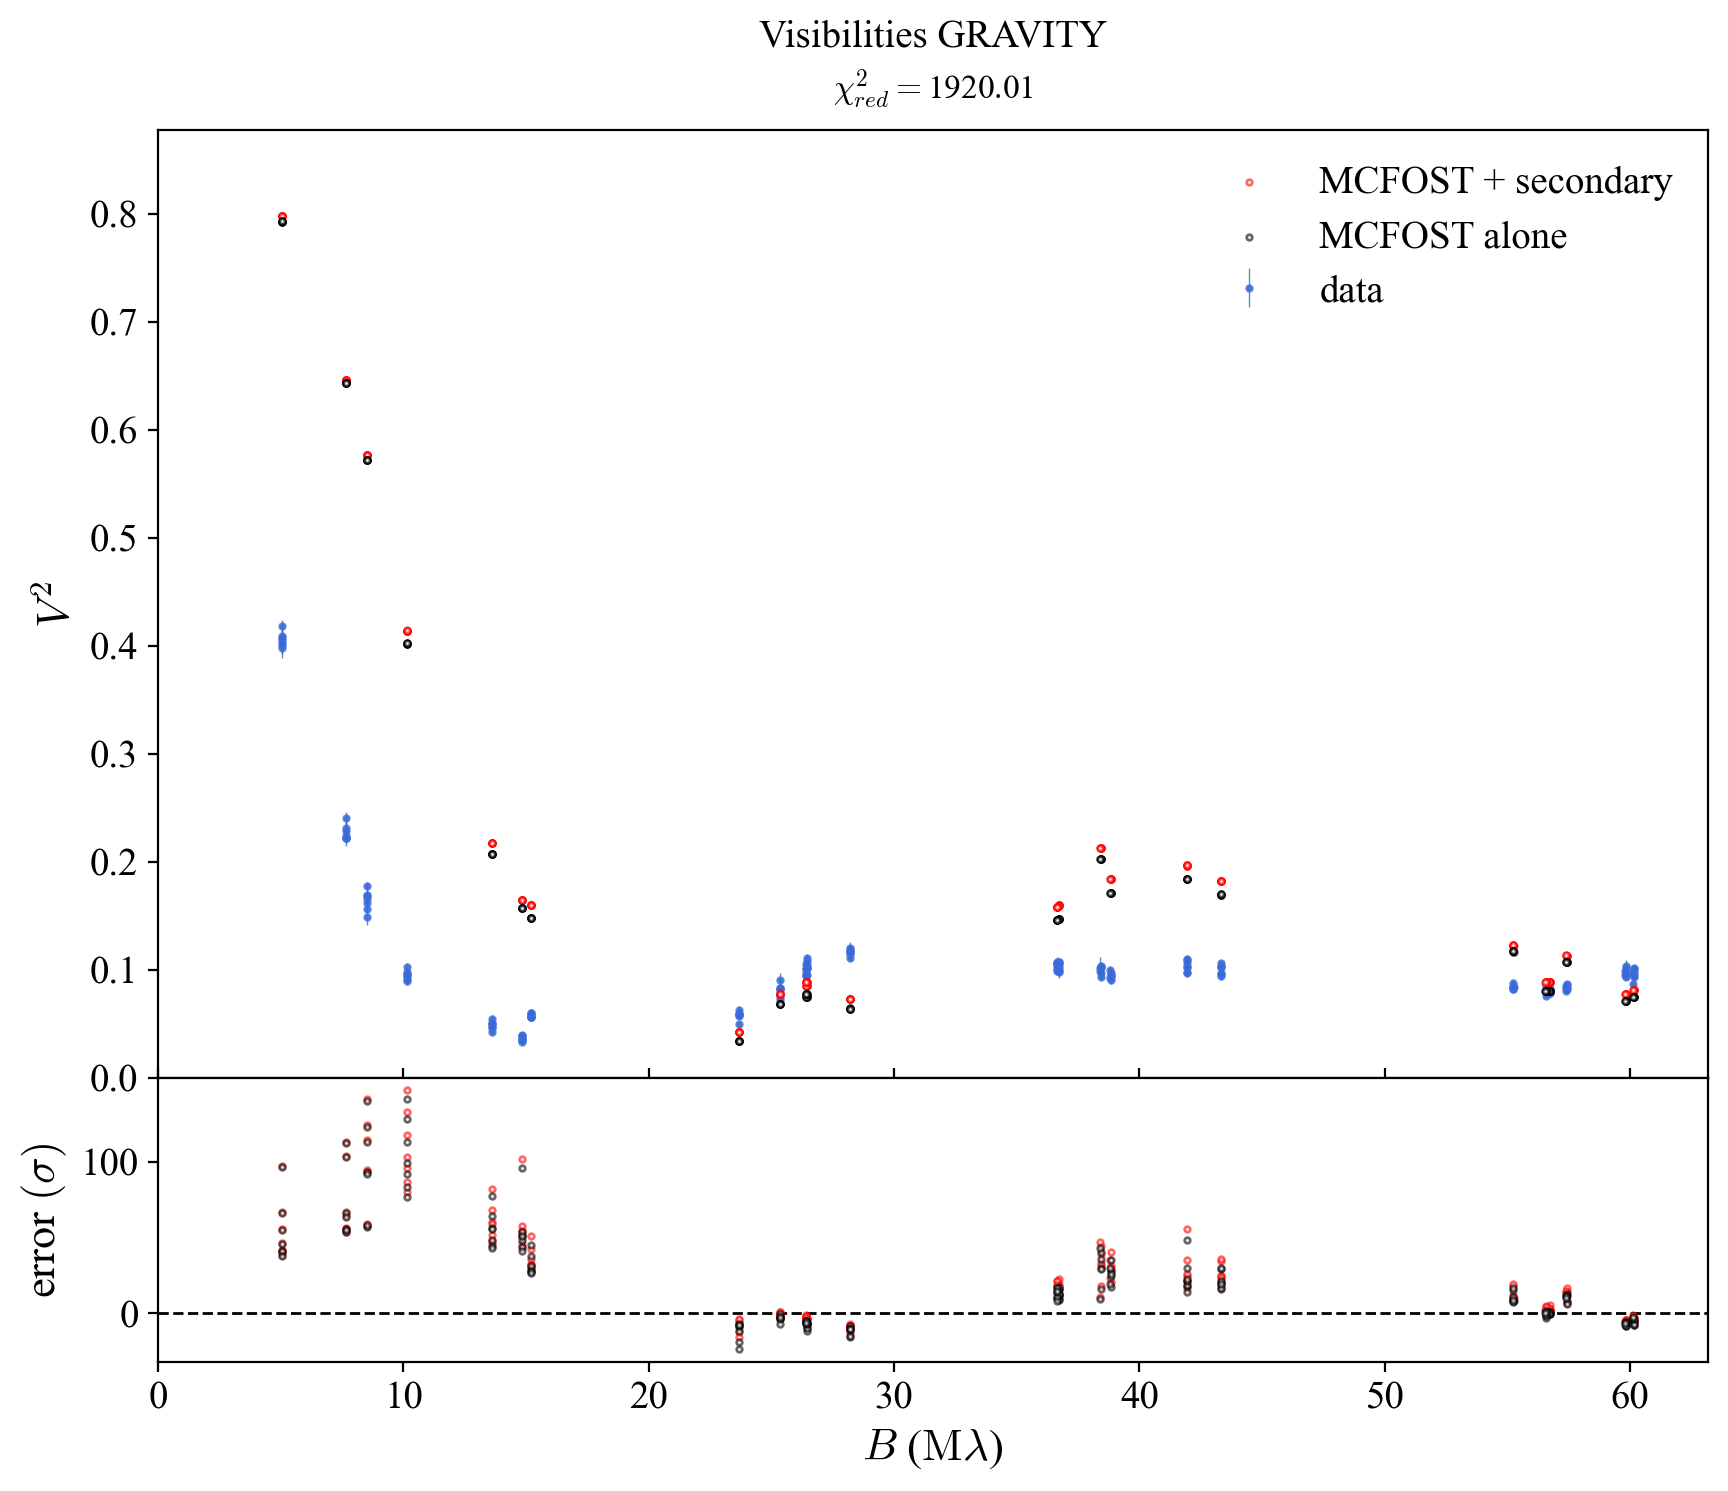

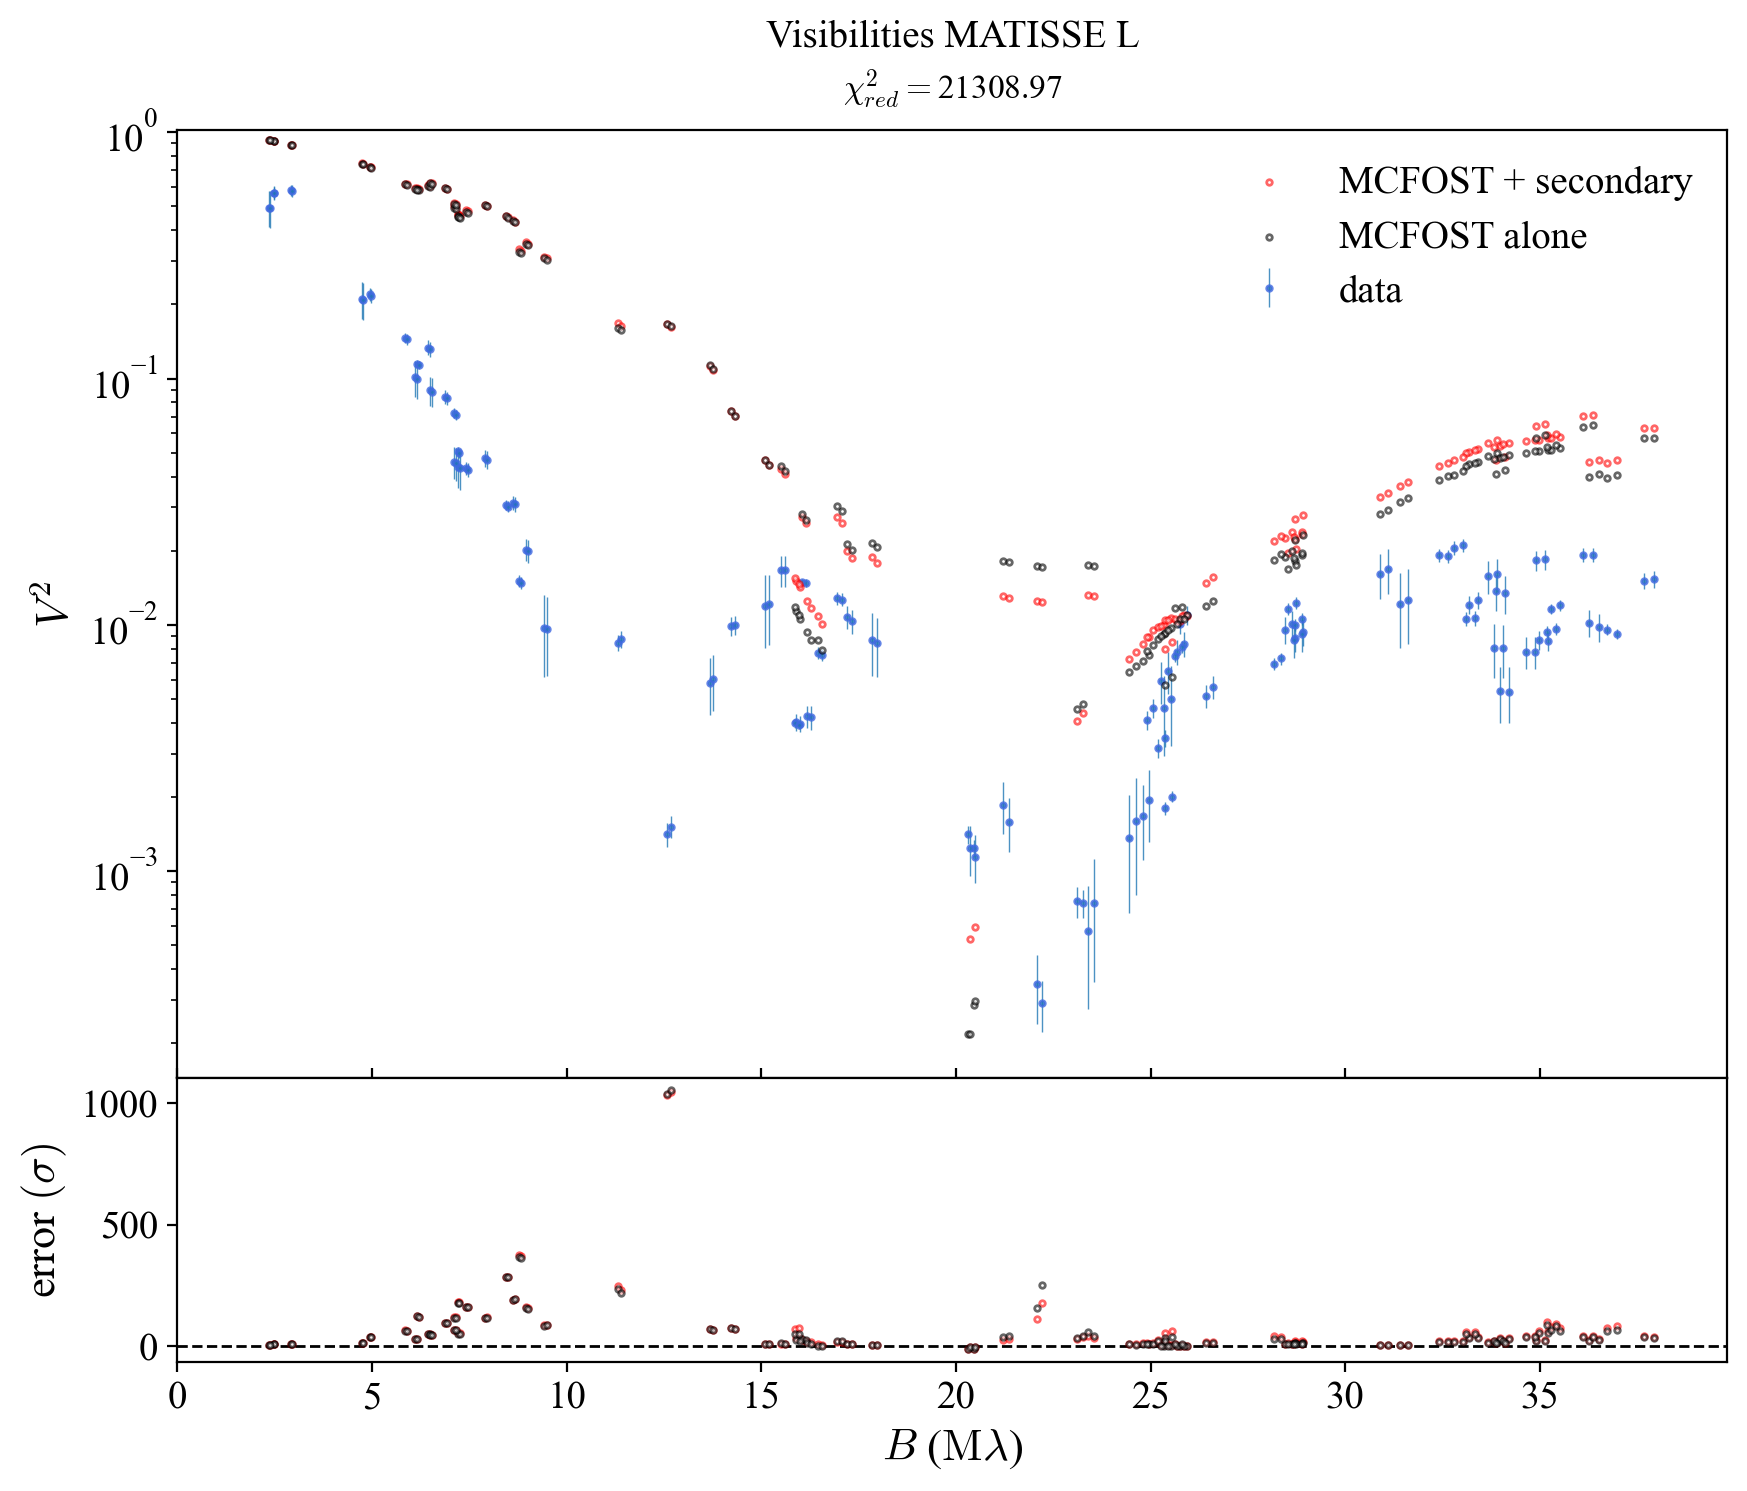

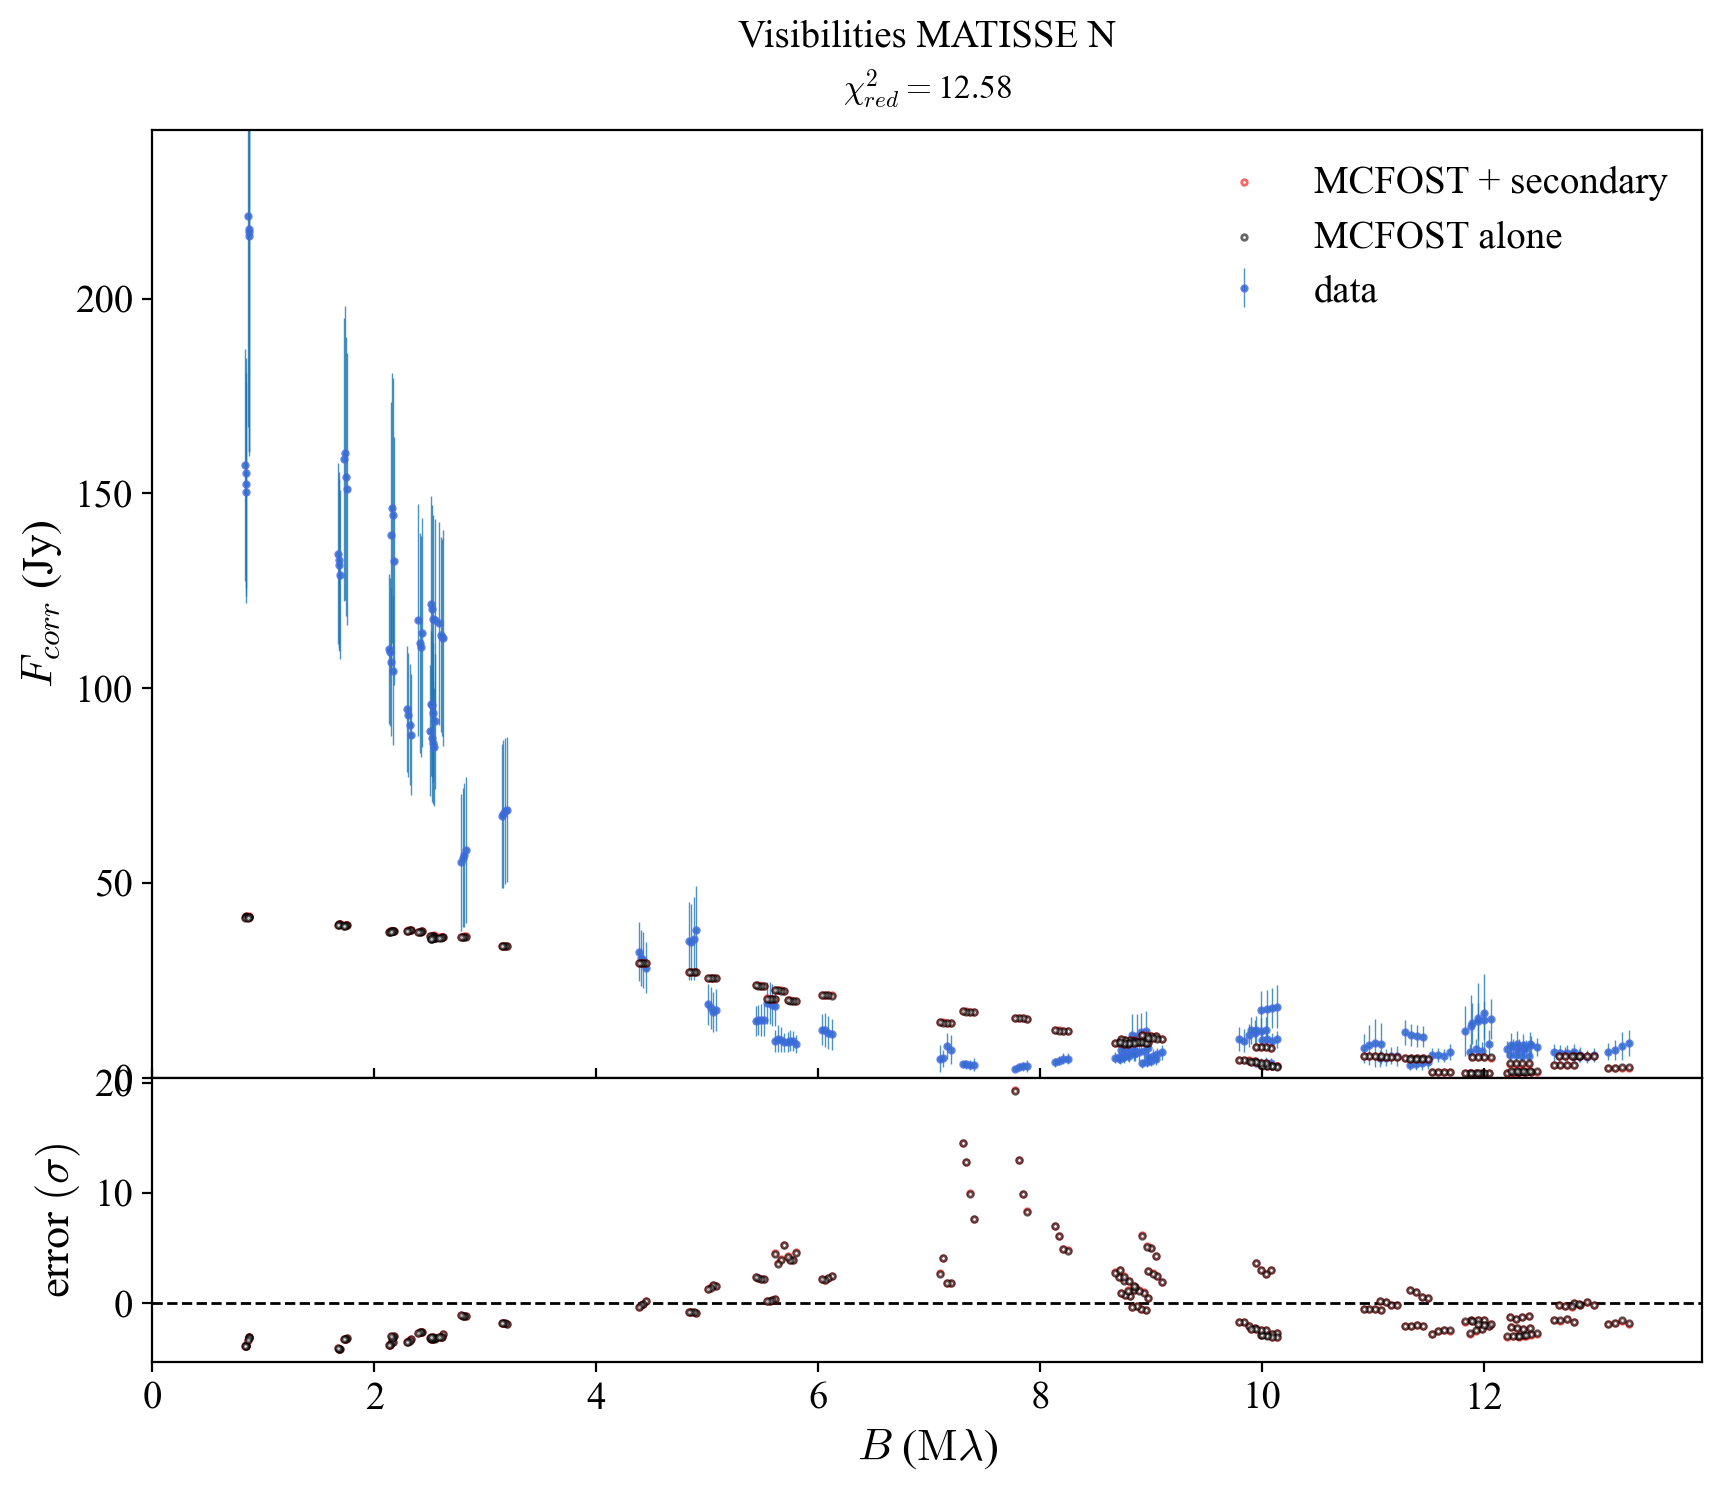

,band,stage,chi2,chi2_per_Nminus1,N
0,PIONIER,MCFOST only,1.115418e+04,81.417383,138
1,PIONIER,+ secondary,1.040335e+04,75.936882,138
2,GRAVITY,MCFOST only,2.967394e+05,1776.882643,168
3,GRAVITY,+ secondary,3.206418e+05,1920.011048,168
4,MATISSE L,MCFOST only,3.301868e+06,21302.377002,156
5,MATISSE L,+ secondary,3.302890e+06,21308.969245,156
6,MATISSE N,MCFOST only,2.682377e+03,12.476174,216
7,MATISSE N,+ secondary,2.703975e+03,12.576629,216


PASS: extinction consistency checks for loaded bands.


In [35]:
sed_if_results = {}
if not sed_if_ready or not sed_if_bands:
    print('SKIPPED: load SED and at least one interferometric band first.')
else:
    rows = []
    for name, band in sed_if_bands.items():
        data, images, vistype = band['data'], band['images'], band['vistype']
        stages = obi.plot_secondary_comparison(
            data, images, sed_if_model_sed, str(SED_IF_PLOT_DIR), vistype,
            name, name == 'MATISSE L', sed_if_ebv, str(SED_IF_LAW))
        baseline, secondary = stages['MCFOST only'], stages['+ secondary']
        output = SED_IF_PLOT_DIR / 'secondary_comparison' / f'visibilities_{name}.{obi.constants.FIG_OUTPUT_TYPE}'
        display(Image(filename=str(output)))
        secondary_intrinsic = obi.calc_observables_with_secondary(data, images, sed_if_model_sed)
        np.testing.assert_allclose(secondary.v2, secondary_intrinsic.v2, equal_nan=True)
        if secondary.vis_in_fcorr:
            np.testing.assert_allclose(secondary.v, obs.redden_flux(
                secondary.v_wave, secondary_intrinsic.v, str(SED_IF_LAW), sed_if_ebv), equal_nan=True)
        field = 'v2' if vistype == 'vis2' else 'v'
        measured = getattr(data, field)
        errors = getattr(data, field + '_err')
        x = getattr(data, field + '_base')
        assert np.all(np.isfinite(measured)) and np.all(np.isfinite(errors)) and np.all(errors > 0)
        assert len(measured) > 1
        for label, model in stages.items():
            prediction = getattr(model, field)
            assert np.all(np.isfinite(prediction))
            chi2, reduced, _, n = obi.oi_container_chi2(data, model, vistype=vistype)
            rows.append(dict(band=name, stage=label, chi2=chi2, chi2_per_Nminus1=reduced, N=n))
        sed_if_results[name] = stages
    display(pd.DataFrame(rows))
    print('PASS: extinction consistency checks for loaded bands.')